In [1]:
import os
os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/"
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import xarray as xr
import netCDF4 as nc
from netCDF4 import Dataset
import scipy as sp

import datetime
import cftime
import time

import gsw

In [152]:
def make_land_mask(ds, inds):
    if np.ma.make_mask(ds['vosaline'][0,0,inds[0]:inds[1], inds[2]:inds[3]] != 0).all() == 1:
        mask = np.ma.make_mask(~np.isnan(ds['vosaline'][0,0,inds[0]:inds[1], inds[2]:inds[3]]))
    else:
        mask = np.ma.make_mask(ds['vosaline'][0,0,inds[0]:inds[1], inds[2]:inds[3]] != 0)
    return mask

def isopycnal_interp(ds, inds, isopycnal):
    try:
        s = gsw.SA_from_Sstar(ds['vosaline'] * (35.16504/35), 10.1325, ds.nav_lon_grid_T, ds.nav_lat_grid_T)
    except: 
        s = gsw.SA_from_Sstar(ds['vosaline'] * (35.16504/35), 10.1325, ds.nav_lon, ds.nav_lat)
        
    rho = gsw.sigma0(s, ds['votemper'])[0,:,inds[0]:inds[1], inds[2]:inds[3]]
    rho = np.where(rho > 0, rho, np.nan)

    iso = isopycnal
    residuals = rho - iso

    stacked_ones = np.vstack([residuals, np.ones((1, rho[0,:,:].shape[0], rho[0,:,:].shape[1]))])
    #print(stacked_ones.shape)
    depths = np.stack([np.stack([ds.deptht] * rho[0,:,:].shape[0], axis=1)]*rho[0,:,:].shape[1], axis=2)
    #print(depths.shape)
        
    schange = stacked_ones[:-1,:,:] * stacked_ones[1:,:,:]
    #print(schange.shape)

    m_rho = np.ma.make_mask(schange < 0)
    m_rho1 = np.insert(m_rho, 0, np.zeros((rho[0,:,:].shape[0], rho[0,:,:].shape[1])).astype(bool), axis=0)[:-1,:,:]

    rho1 = np.nansum(np.where(m_rho, rho, np.nan), axis=0)
    rho2 = np.nansum(np.where(m_rho1, rho, np.nan), axis=0)
    #print(rho2.shape)

    z1 = np.nansum(np.where(m_rho, depths, np.nan), axis=0)
    z2 = np.nansum(np.where(m_rho1, depths, np.nan), axis=0)
    #print(z2.shape)

    zs2interp = np.stack([z1,z2], axis=0) #monotonically increasing down
    rhos2interp = np.stack([rho1,rho2], axis=0) #monotonically increasing down

    interp_outz = np.zeros((rho[0,:,:].shape[0], rho[0,:,:].shape[1]))
    #print(interp_outz.shape)

    for x in range(rho[0,:,:].shape[0]):
        for y in range(rho[0,:,:].shape[1]):
            interp_outz[x,y] = np.interp(iso, rhos2interp[:,x,y], zs2interp[:,x,y])
            
    land_mask = make_land_mask(ds, inds)
    #print(land_mask.shape)

    return [m_rho, m_rho1, interp_outz, zs2interp, land_mask]


def isopycnal_proj(var_proj, inds, interprod):
    var = var_proj[0,:,inds[0]:inds[1], inds[2]:inds[3]]
    var1 = np.nansum(np.where(interprod[0], var, np.nan), axis=0)
    #print(var1.shape)
    var2 = np.nansum(np.where(interprod[1], var, np.nan), axis=0)
    #print(var2.shape)

    interp_vars = np.stack([var1,var2], axis=0)

    var_out = np.zeros((interprod[4].shape[0], interprod[4].shape[1]))
    #print(var_out.shape)

    for x in range(interprod[4].shape[0]):
        for y in range(interprod[4].shape[1]):
            var_out[x,y] = np.interp(interprod[2][x,y], interprod[3][:,x,y], interp_vars[:,x,y])
        
    var_out = np.where(interprod[4], var_out, np.nan)

    return var_out
    

In [153]:
"""
class nlcmap():
    "A nonlinear colormap"
    
    name = 'nlcmap'
    
    def __init__(self, cmap, levels):
        self.cmap = cmap
        # @MRR: Need to add N for backend
        self.N = cmap.N
        self.monochrome = self.cmap.monochrome
        self.levels = asarray(levels, dtype='float64')
        self._x = self.levels / self.levels.max()
        self._y = linspace(0.0, 1.0, len(self.levels))
    
    #@MRR Need to add **kw for 'bytes'
    def __call__(self, xi, alpha=1.0, **kw):
        "docstring for fname
        # @MRR: Appears broken? 
        # It appears something's wrong with the
        # dimensionality of a calculation intermediate
        #yi = stineman_interp(xi, self._x, self._y)
        yi = interp(xi, self._x, self._y)
        return self.cmap(yi, alpha)


if __name__ == '__main__':
    
    y, x = mgrid[0.0:3.0:100j, 0.0:5.0:100j]
    H = 50.0 * exp( -(x**2 + y**2) / 4.0 )
    levels = [0, 1, 2, 3, 6, 9, 20, 50]
    
    cmap_lin = cm.jet
    cmap_nonlin = nlcmap(cmap_lin, levels)
    
    subplot(2,1,1)
    contourf(x, y, H, levels, cmap=cmap_nonlin)
    colorbar()
    subplot(2,1,2)
    contourf(x, y, H, levels, cmap=cmap_lin)
    colorbar()
    
    savefig('nlcmap_example.png')
"""

'\nclass nlcmap():\n    "A nonlinear colormap"\n    \n    name = \'nlcmap\'\n    \n    def __init__(self, cmap, levels):\n        self.cmap = cmap\n        # @MRR: Need to add N for backend\n        self.N = cmap.N\n        self.monochrome = self.cmap.monochrome\n        self.levels = asarray(levels, dtype=\'float64\')\n        self._x = self.levels / self.levels.max()\n        self._y = linspace(0.0, 1.0, len(self.levels))\n    \n    #@MRR Need to add **kw for \'bytes\'\n    def __call__(self, xi, alpha=1.0, **kw):\n        "docstring for fname\n        # @MRR: Appears broken? \n        # It appears something\'s wrong with the\n        # dimensionality of a calculation intermediate\n        #yi = stineman_interp(xi, self._x, self._y)\n        yi = interp(xi, self._x, self._y)\n        return self.cmap(yi, alpha)\n\n\nif __name__ == \'__main__\':\n    \n    y, x = mgrid[0.0:3.0:100j, 0.0:5.0:100j]\n    H = 50.0 * exp( -(x**2 + y**2) / 4.0 )\n    levels = [0, 1, 2, 3, 6, 9, 20, 50]\n   

working on nonlinear colormap but priority B

In [154]:
# Source - https://stackoverflow.com/a/43385541
# Posted by ImportanceOfBeingErnest
# Retrieved 2026-04-08, License - CC BY-SA 3.0

cmap = mpl.cm.viridis.copy()
cmaplist = [cmap(i) for i in range(cmap.N)]
cmaplist[0] = (1.0,1.0,1.0,1.0)
cmap = mpl.colors.LinearSegmentedColormap.from_list('mcm',cmaplist, cmap.N)

projection.shape
n = 20
a=np.nanmax(projection)
b=np.nanmin(projection[projection !=0])
level = np.linspace(b, b + (a-b)/2, int(n/4))
level2 = np.linspace(b + (a-b)/2, a, 3*int(n/4))
levels = np.append(level, [level2])

def make_nonlinear_cb(cb, levels):
    cmap = mpl.cm.cb.copy()
    

In [155]:
def projection_plotter(projection, num, colorscheme, name, model, mask):

    projection = np.where(mask, projection, np.nan)

    a=np.nanmax(projection)
    print(a)
    b=np.nanmin(projection[projection != 0])
    print(b)

    c = (a-b) / num
    print(c)

    cmap = plt.get_cmap(colorscheme).copy() # Make a copy to avoid changing the original
    cmap.set_under('black', alpha=.5)
    plt.contourf(projection, np.arange(b, a, c),cmap=cmap, extend='min')
    plt.colorbar()
    
    plt.title(name + " projected onto " + str(rho_goal) + " kg/m3 isopycnal, 5/25/2018 " + "(" + model + ")" , fontsize = 9.5)

    if model == 'ANHA4':
        plt.yticks(np.arange(25,200, 25), np.trunc(ds_t4.nav_lat_grid_T.values[275:450, 150][::25] * 100) / 100)
        plt.xticks(np.arange(25,225, 45), np.trunc(ds_t4.nav_lon_grid_T.values[250, 175:375][::45] * 100) / 100)
    else:
        plt.yticks(np.arange(75,600, 75), np.trunc(ds_t12.nav_lat.values[825:1350, 450][::75] * 100) / 100)
        plt.xticks(np.arange(75,675, 135), np.trunc(ds_t12.nav_lon.values[750, 525:1125][::135] * 100) / 100)
        
    plt.ylabel('Latitude')
    plt.xlabel('Longitude')

    plt.show()


In [156]:
ds_t4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25_gridT.nc")
ds_t12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2018m05d25_gridT.nc")

In [157]:
np.nanmean(interprods12[3][interprods12[3] != 0])

1150.4122

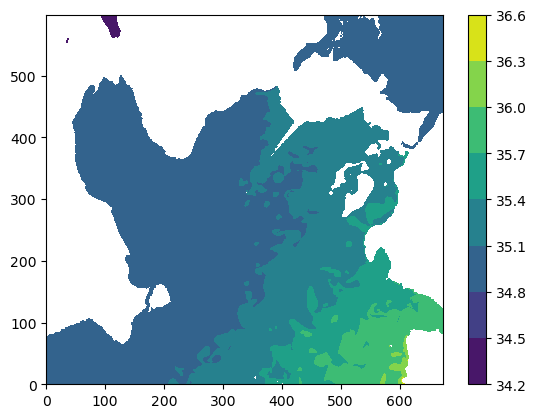

In [158]:
plt.contourf(ds_t12['vosaline'][0, 35, 750:1350, 450:1125])
plt.colorbar()

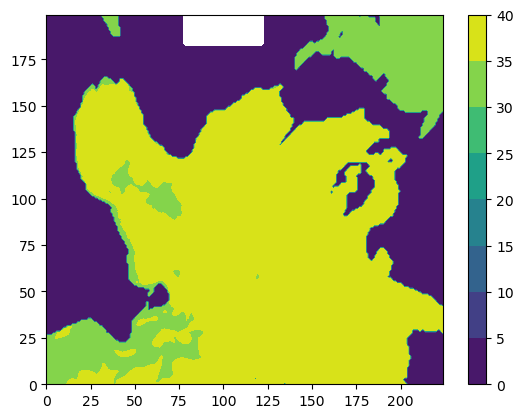

In [159]:
plt.contourf(ds_t4['vosaline'][0, 35, 250:450,150:375])
plt.colorbar()

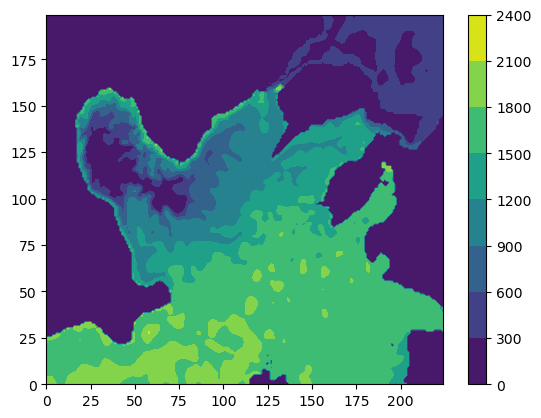

In [160]:
plt.contourf(interprods4[2])
plt.colorbar()

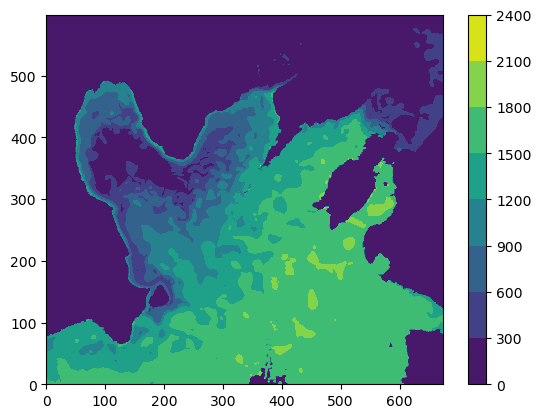

In [161]:
plt.contourf(interprods12[2])
plt.colorbar()

In [166]:
rho_goal = 27.76
interprods4 = isopycnal_interp(ds_t4, [250,450,150,375], rho_goal)

In [167]:
interprods12 = isopycnal_interp(ds_t12, [750, 1350, 450, 1125], rho_goal)

In [168]:
proj12sal = isopycnal_proj(ds_t12['vosaline'], [750, 1350, 450, 1125], interprods12)

70.33131408691406
34.49391751798981
1.1945798856308085


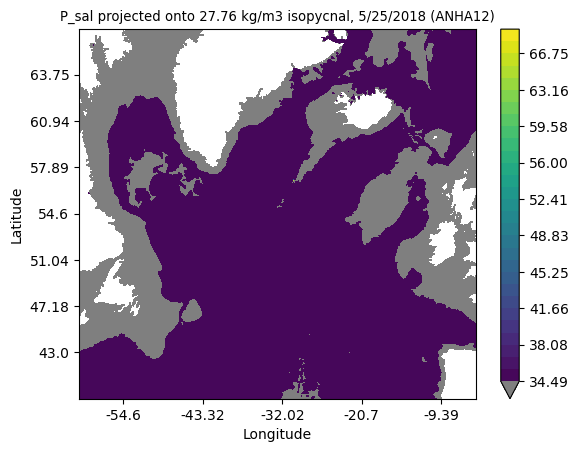

In [170]:
projection_plotter(proj12sal, 30, 'viridis', "P_sal", 'ANHA12', mask = interprods12[4])

10.945516586303711
-1.3984482355357124
0.4114654940613141


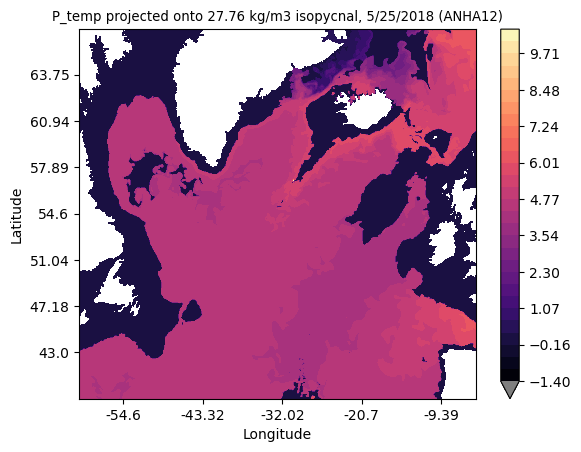

In [110]:
proj12h = isopycnal_proj(ds_t12['votemper'], [750, 1350, 450, 1125], interprods12)
projection_plotter(proj12h, 30, 'magma', "P_temp", 'ANHA12', mask = interprods12[4])

In [171]:
proj4sal = isopycnal_proj(ds_t4['vosaline'], [250,450,150,375], interprods4)

35.39896881408634
34.70822672058645
0.02302473644999618


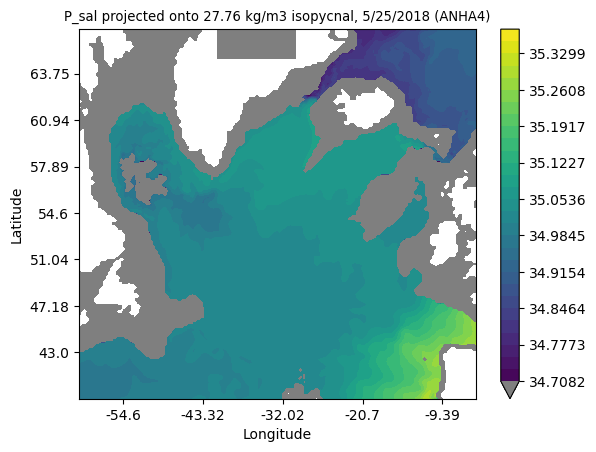

In [172]:
projection_plotter(proj4sal, 30, 'viridis', "P_sal", 'ANHA4', interprods4[4])

6.73574140642328
1.737395714787308
0.1666115230545324


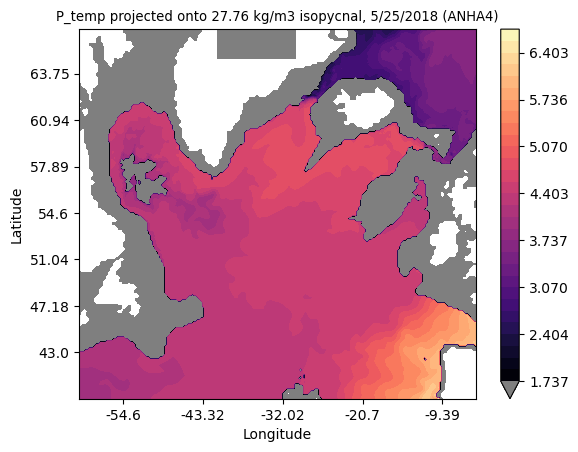

In [115]:
proj4h = isopycnal_proj(ds_t4['votemper'], [250,450,150,375], interprods4)
projection_plotter(proj4h, 30, 'magma', "P_temp", 'ANHA4', interprods4[4])